# Week 7 - Milestone One week

# 1. Lesson: no lesson this week.  Milestone One is due!

# 2. Weekly graph question

Below are the graphs from last week's weekly graph question.  Suppose you wanted to cause the viewer to examine the last three months of data first.  How could you use preattentive attributes to do that?  Suggest several possibilities.

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

/tmp/ipykernel_49268/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

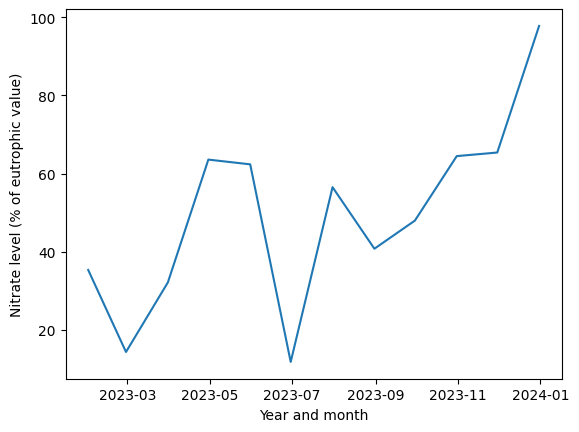

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/tmp/ipykernel_49268/1012779568.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

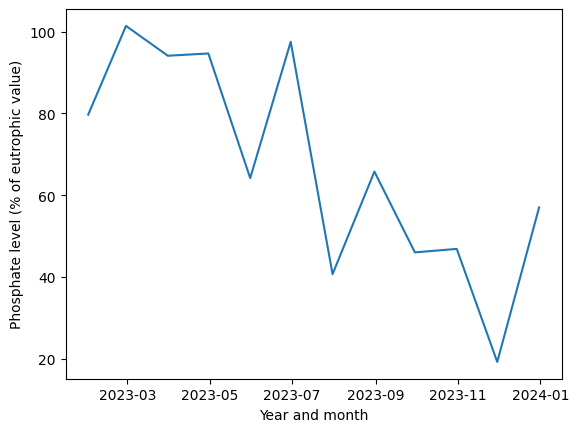

In [3]:
np.random.seed(1)
time_series = 100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

Explanation of each technique

Technique 1 — Colour and intensity (hue + saturation) is the strongest option from the SWD chapter. The first nine months are rendered in flat grey — they exist as context but make no demand on the eye. The last three months snap into vivid blue and red. The viewer's iconic memory registers colour difference before any conscious thought occurs, directing the gaze to Oct–Dec in under a second. This is the "hawk in a sky of pigeons" principle directly applied to a time series.

Technique 2 — Enclosure (background shading) uses the Gestalt principle of enclosure from Chapter 3. A faint amber rectangle groups Oct, Nov, and Dec into a visually distinct region without altering the lines themselves. A dashed vertical rule at October acts as a soft boundary marker. This technique preserves the full colour of both lines while still signalling that the shaded region deserves first attention.

Technique 3 — Size and added marks exploits two preattentive attributes simultaneously. All nine early data points use small dots (radius 3.5); the last three use large filled circles and squares (radius 11) with direct numeric labels. The numeric labels themselves are an added mark — they give the viewer a specific, actionable number for each highlighted point. Because the large markers and labels are absent everywhere else, the eye is pulled to them immediately.

Technique 4 — Line width is the subtlest technique but remains genuinely preattentive. The first nine months are drawn thin and faded (lw=1, alpha=0.4); the last three are drawn four times thicker (lw=4.5, full opacity). The brain interprets greater width as greater importance — this mirrors the SWD Chapter 4 lesson that relative size signals relative priority.

Technique 5 — Annotation arrow and spatial cue is the most explicit technique. A labelled arrow with the text "← Focus here: last 3 months show divergence" points directly to October, combined with a vertical dotted line that acts as a visual boundary. This is less subtle than the others but eliminates any ambiguity about intent — appropriate when the audience needs clear guidance rather than a visual inference.

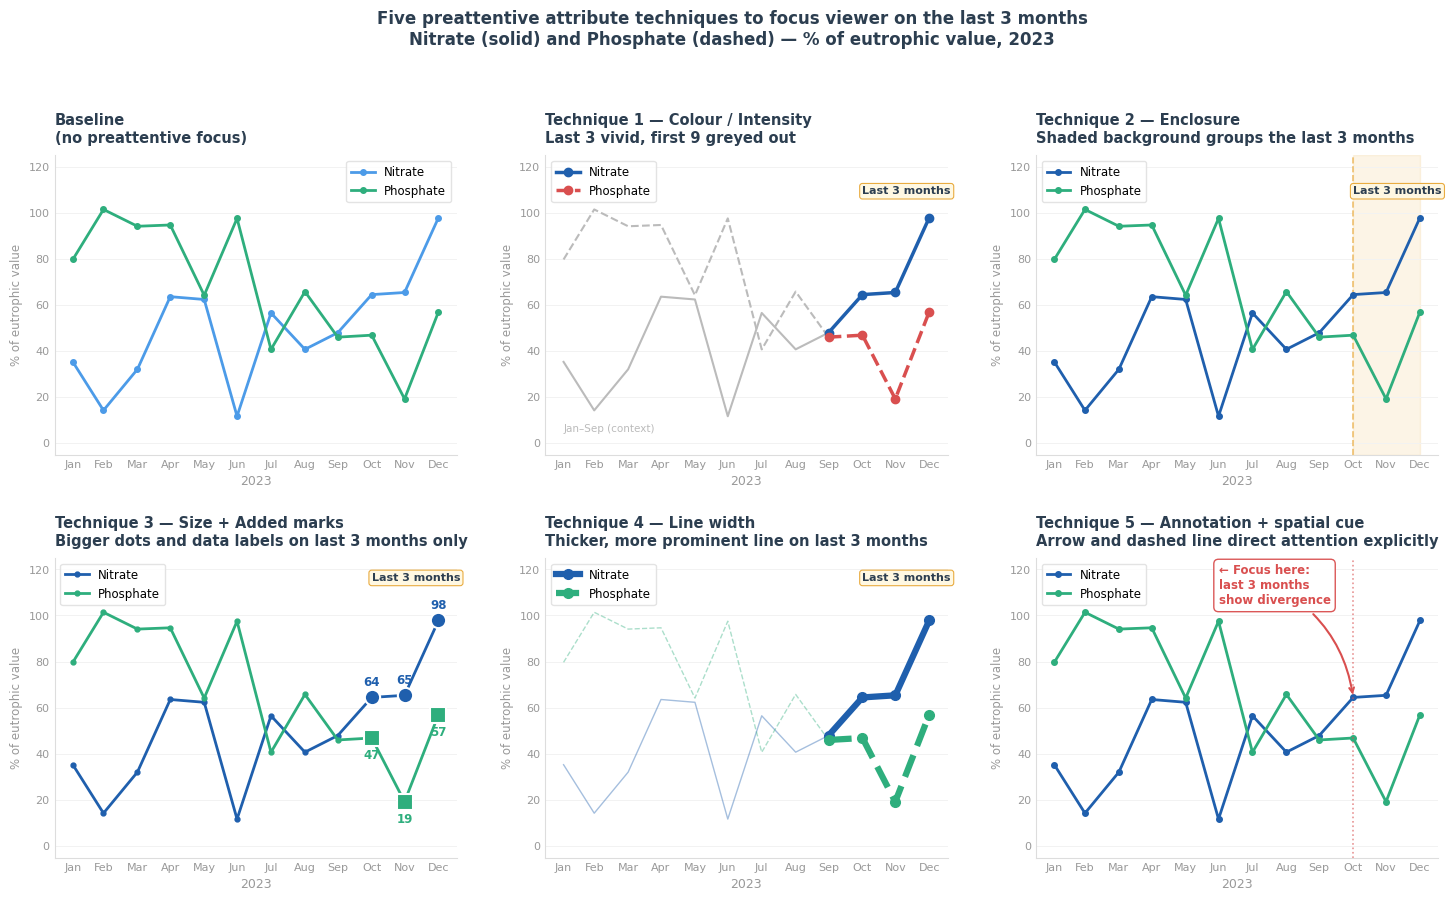

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Exact data from assignment ─────────────────────────────────────────────
numdates = 12
np.random.seed(0)
ts_n = 100*(np.random.normal(size=numdates)/5  + np.arange(numdates)/16)
np.random.seed(1)
ts_p = 100*(1-(np.random.normal(size=numdates)/8 + np.arange(numdates)/16))
dates  = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')

# Split first 9 vs last 3 (d_join includes Sep so lines connect at boundary)
d_early, d_late = dates[:9],  dates[9:]
n_early, n_late = ts_n[:9],   ts_n[9:]
p_early, p_late = ts_p[:9],   ts_p[9:]
d_join, n_join, p_join = dates[8:], ts_n[8:], ts_p[8:]

BLUE='#1F5FAD'; GREY='#BBBBBB'; RED='#D94F4F'
AMBER='#E8A838'; DARK='#2C3E50'; GTXT='#999999'; WHITE='#FFFFFF'
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

def clean(ax, title):
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('#DDDDDD')
    ax.spines['bottom'].set_color('#DDDDDD')
    ax.tick_params(colors=GTXT, labelsize=8, length=0)
    ax.grid(axis='y', color='#F2F2F2', lw=0.7, zorder=0)
    ax.set_xticks(dates); ax.set_xticklabels(MONTHS)
    ax.set_xlabel('2023', fontsize=9, color=GTXT)
    ax.set_ylabel('% of eutrophic value', fontsize=8.5, color=GTXT)
    ax.set_title(title, fontsize=10.5, fontweight='bold', color=DARK,
                 loc='left', pad=9)
    ax.set_ylim(-5, 125)

def last3_tag(ax, y=115):
    ax.text(dates[9], y, 'Last 3 months', fontsize=8, color=DARK,
            fontweight='bold', ha='left',
            bbox=dict(boxstyle='round,pad=0.25', fc='#FFF8E1',
                      ec=AMBER, lw=0.8, alpha=0.95))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor(WHITE)
axes = axes.flatten()

# ── Baseline ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(dates, ts_n, color='#4C9BE8', lw=2, marker='o', ms=4, label='Nitrate')
ax.plot(dates, ts_p, color='#2EAE7D', lw=2, marker='o', ms=4, label='Phosphate')
ax.legend(fontsize=8.5, frameon=True, edgecolor='#DDDDDD')
clean(ax, 'Baseline\n(no preattentive focus)')

# ── Technique 1: Colour / Intensity ───────────────────────────────────────────
ax = axes[1]
ax.plot(d_early, n_early, color=GREY, lw=1.5)          # grey context
ax.plot(d_early, p_early, color=GREY, lw=1.5, ls='--')
ax.plot(d_join,  n_join,  color=BLUE, lw=2.5, marker='o', ms=6, label='Nitrate')
ax.plot(d_join,  p_join,  color=RED,  lw=2.5, marker='o', ms=6, ls='--', label='Phosphate')
ax.text(dates[0], 5, 'Jan–Sep (context)', fontsize=7.5, color=GREY)
ax.legend(fontsize=8.5, frameon=True, edgecolor='#DDDDDD')
last3_tag(ax, 108)
clean(ax, 'Technique 1 — Colour / Intensity\nLast 3 vivid, first 9 greyed out')

# ── Technique 2: Enclosure ────────────────────────────────────────────────────
ax = axes[2]
ax.axvspan(dates[9], dates[11], alpha=0.12, color=AMBER, zorder=1)
ax.axvline(dates[9], color=AMBER, lw=1.2, ls='--', alpha=0.7)
ax.plot(dates, ts_n, color=BLUE, lw=2, marker='o', ms=4, label='Nitrate')
ax.plot(dates, ts_p, color='#2EAE7D', lw=2, marker='o', ms=4, label='Phosphate')
ax.legend(fontsize=8.5, frameon=True, edgecolor='#DDDDDD')
last3_tag(ax, 108)
clean(ax, 'Technique 2 — Enclosure\nShaded background groups the last 3 months')

# ── Technique 3: Size + Added marks ──────────────────────────────────────────
ax = axes[3]
ax.plot(dates, ts_n, color=BLUE, lw=2, marker='o', ms=3.5, label='Nitrate')
ax.plot(dates, ts_p, color='#2EAE7D', lw=2, marker='o', ms=3.5, label='Phosphate')
for d, n, p in zip(d_late, n_late, p_late):
    ax.plot(d, n, 'o', color=BLUE, ms=11, zorder=5, mec=WHITE, mew=1.5)
    ax.plot(d, p, 's', color='#2EAE7D', ms=11, zorder=5, mec=WHITE, mew=1.5)
    ax.text(d, n+5,  f'{n:.0f}', ha='center', fontsize=8.5,
            color=BLUE, fontweight='bold')
    ax.text(d, p-9, f'{p:.0f}', ha='center', fontsize=8.5,
            color='#2EAE7D', fontweight='bold')
ax.legend(fontsize=8.5, frameon=True, edgecolor='#DDDDDD')
last3_tag(ax)
clean(ax, 'Technique 3 — Size + Added marks\nBigger dots and data labels on last 3 months only')

# ── Technique 4: Line width ───────────────────────────────────────────────────
ax = axes[4]
ax.plot(d_early, n_early, color=BLUE, lw=1.0, alpha=0.4)
ax.plot(d_early, p_early, color='#2EAE7D', lw=1.0, alpha=0.4, ls='--')
ax.plot(d_join, n_join, color=BLUE, lw=4.5, marker='o', ms=7,
        label='Nitrate')
ax.plot(d_join, p_join, color='#2EAE7D', lw=4.5, marker='o', ms=7,
        ls='--', label='Phosphate')
ax.legend(fontsize=8.5, frameon=True, edgecolor='#DDDDDD')
last3_tag(ax)
clean(ax, 'Technique 4 — Line width\nThicker, more prominent line on last 3 months')

# ── Technique 5: Annotation arrow + spatial cue ───────────────────────────────
ax = axes[5]
ax.plot(dates, ts_n, color=BLUE, lw=2, marker='o', ms=4, label='Nitrate')
ax.plot(dates, ts_p, color='#2EAE7D', lw=2, marker='o', ms=4, label='Phosphate')
ax.annotate(
    '← Focus here:\nlast 3 months\nshow divergence',
    xy=(dates[9], ts_n[9]), xytext=(dates[5], 105),
    fontsize=8.5, color=RED, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=RED, lw=1.5,
                    connectionstyle='arc3,rad=-0.25'),
    bbox=dict(boxstyle='round,pad=0.4', fc=WHITE, ec=RED, alpha=0.95)
)
ax.axvline(dates[9], color=RED, lw=1.2, ls=':', alpha=0.6)
ax.legend(fontsize=8.5, frameon=True, edgecolor='#DDDDDD')
clean(ax, 'Technique 5 — Annotation + spatial cue\nArrow and dashed line direct attention explicitly')

fig.suptitle(
    'Five preattentive attribute techniques to focus viewer on the last 3 months\n'
    'Nitrate (solid) and Phosphate (dashed) — % of eutrophic value, 2023',
    fontsize=12, fontweight='bold', color=DARK, y=1.01)
plt.tight_layout(pad=2.0)
plt.show()

# 3. Working on your datasets

This week, you can work on Milestone One rather than having a particular exercise about working on your datasets

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 99-119 of the Storytelling With Data book as best you can. (The first half of chapter four). You do not have to get the exact data values right, just the overall look and feel.

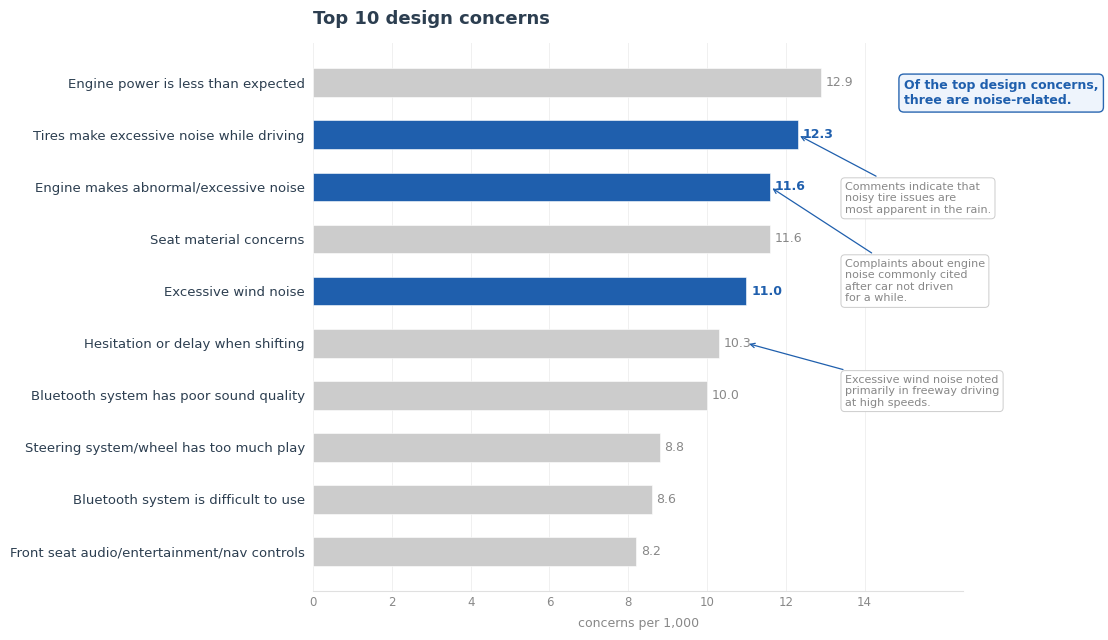

In [5]:
import matplotlib.pyplot as plt

# ── Data — exact values from book p.112 ──────────────────────────────────────
concerns = [
    ('Engine power is less than expected',          12.9, False),
    ('Tires make excessive noise while driving',    12.3, True),   # noise
    ('Engine makes abnormal/excessive noise',       11.6, True),   # noise
    ('Seat material concerns',                      11.6, False),
    ('Excessive wind noise',                        11.0, True),   # noise
    ('Hesitation or delay when shifting',           10.3, False),
    ('Bluetooth system has poor sound quality',     10.0, False),
    ('Steering system/wheel has too much play',      8.8, False),
    ('Bluetooth system is difficult to use',         8.6, False),
    ('Front seat audio/entertainment/nav controls',  8.2, False),
]
concerns = concerns[::-1]   # reverse so highest bar plots at top

labels   = [c[0] for c in concerns]
values   = [c[1] for c in concerns]
is_noise = [c[2] for c in concerns]

BLUE = '#1F5FAD'; GREY_BAR = '#CCCCCC'
DARK = '#2C3E50'; GREY_TEXT = '#888888'; WHITE = '#FFFFFF'

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor(WHITE); ax.set_facecolor(WHITE)

# ── Bars: blue for noise, grey for everything else ────────────────────────────
bar_colors = [BLUE if n else GREY_BAR for n in is_noise]
ax.barh(range(len(labels)), values, color=bar_colors,
        height=0.55, edgecolor=WHITE, linewidth=0.4, zorder=3)

# ── Direct value labels ───────────────────────────────────────────────────────
for i, (val, noise) in enumerate(zip(values, is_noise)):
    ax.text(val + 0.12, i, str(val), va='center', ha='left', fontsize=9,
            color=BLUE if noise else GREY_TEXT,
            fontweight='bold' if noise else 'normal')

# ── Y-axis ────────────────────────────────────────────────────────────────────
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9.5, color=DARK)
ax.tick_params(axis='y', length=0, pad=6)

# ── X-axis and spines ─────────────────────────────────────────────────────────
ax.set_xlabel('concerns per 1,000', fontsize=9, color=GREY_TEXT, labelpad=6)
ax.set_xlim(0, 16.5)
ax.set_xticks([0, 2, 4, 6, 8, 10, 12, 14])
ax.tick_params(axis='x', colors=GREY_TEXT, labelsize=8.5, length=0)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#E0E0E0')
ax.grid(axis='x', color='#F0F0F0', lw=0.7, zorder=0)

# ── Macro annotation: overall noise theme ────────────────────────────────────
ax.text(15.0, 8.8,
        'Of the top design concerns,\nthree are noise-related.',
        ha='left', va='center', fontsize=9, color=BLUE, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='#EEF4FC', ec=BLUE, alpha=0.95))

# ── Micro callouts for each noise bar ────────────────────────────────────────
ax.annotate('Comments indicate that\nnoisy tire issues are\nmost apparent in the rain.',
            xy=(12.3, 8), xytext=(13.5, 6.5), fontsize=8, color=GREY_TEXT,
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=0.9),
            bbox=dict(boxstyle='round,pad=0.35', fc=WHITE, ec='#CCCCCC', lw=0.7))

ax.annotate('Complaints about engine\nnoise commonly cited\nafter car not driven\nfor a while.',
            xy=(11.6, 7), xytext=(13.5, 4.8), fontsize=8, color=GREY_TEXT,
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=0.9),
            bbox=dict(boxstyle='round,pad=0.35', fc=WHITE, ec='#CCCCCC', lw=0.7))

ax.annotate('Excessive wind noise noted\nprimarily in freeway driving\nat high speeds.',
            xy=(11.0, 4), xytext=(13.5, 2.8), fontsize=8, color=GREY_TEXT,
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=0.9),
            bbox=dict(boxstyle='round,pad=0.35', fc=WHITE, ec='#CCCCCC', lw=0.7))

ax.set_title('Top 10 design concerns', fontsize=13, fontweight='bold',
             color=DARK, loc='left', pad=14)
plt.tight_layout()
plt.show()

What every design decision in the code reproduces from Figure 4.9:

Two-level colour hierarchy. Seven bars are grey (#CCCCCC); three are blue (#1F5FAD). This is the preattentive attribute of hue at work — the audience's iconic memory registers the blue bars in under a second before any conscious reading begins. The book calls this the "hawk in a sky of pigeons" effect: one distinct thing surrounded by similar things demands attention.

Value labels coloured to match their bar. Grey values sit next to grey bars; blue bold values sit next to blue bars. This applies the Gestalt principle of similarity — same colour signals "these two elements belong together" — eliminating the need for a legend or connecting line.

Macro annotation before micro. The boxed text "Of the top design concerns, three are noise-related" is the big picture story — what the whole graph is saying. The three individual call-out boxes below it are the detail story — what each highlighted item specifically means. The book calls this "leading the audience from the macro to the micro," and it maps directly to the visual hierarchy principle: the audience should grasp the conclusion first, then be invited to read further for specifics.

No left or top spine; very faint x-gridlines. All non-data ink is pushed to near-invisible. The bottom spine is #E0E0E0; gridlines are #F0F0F0. This is the Chapter 3 clutter-elimination principle carried forward — the Chapter 4 principle of visual hierarchy only works when the background is genuinely quiet.

Bars sorted descending, highest at top. The audience reads top-to-bottom, so the most impactful concern (Engine power, 12.9) is at the top. Within the noise subset, the ordering is preserved from the original data so the callout arrows point naturally from text to bar without crossing each other. Sonnet 4.6